# Projektaufgabe: <Titel>

**Vorlesung:** Innovative Konzepte zur Programmierung von Industrierobotern  
**Dozent:** Prof. Dr.-Ing. Björn Hein  
**Gruppe:** Alisa Hummel, Loretta Jacobs, Ole Hocker  
**Aufgabe:** 03- RRT mit kantenbewusster Erweiterung  
**Abgabedatum:** 30.07.2026  
**Vortragsdatum:** 31.07.2026

## 1. Kurzfassung
In dieser Arbeit wird das Konzept des probalisitischen Bahnplanungsverfahren "Rapidly Growing Random Trees (RRT)" um einen kantenbewussten Ansatz erweitert.

Todo: Fassen Sie kurz Problem, Ansatz, wichtigste Ergebnisse und offene Punkte zusammen.

## 2. Einleitung und Zielsetzung
_Autor: Alisa Hummel_

Der Grundaufbau des RRT-Verfahren kann folgendermaßen beschrieben werden:
* Parameter:
    * n = maximale Anzahl von generierten Knoten im Graphen
	* k = nach wie vielen neu erstellten Knoten eine Verbindung zum Zielknoten getestet wird
	* eta = Schrittweite
* Initialisierung: Prüfe Start- und Zielpunkt auf Kollision, füge Startknoten zu leerem Graphen hinzu
* Schleife: solange Anzahl Knoten < n :
	1) **Sampling** neuer random, kollisionsfreier Punkt p_rand
	2) **Nächste-Nachbar-Suche**: Bestimme nächsten Knoten q aus Graph zu Punkt p_rand
	3) **Lokale Erweiterung:** Gehe von Nachbarknoten q die Schrittweite eta in Richtung gesampeltem Punkt p_rand, dadurch neuer Punkt p_n
	4) **Kollisionsprüfung** der Verbindung zwischen dem Nachbarknoten q und dem neuen Punkt p_n
        * wenn Verbindung kollisionsfrei ist, dann p_n als neuen Knoten und Kante zwischen p_n und Nachbar q in Graph einfügen
* Zieltest: Teste nach k neu erstellten Knoten, ob der Zielpunkt kollisionsfrei mit dem Graphen verbunden werden kann. Wenn ja füge Zielknoten und Kante dem Graphen hinzu und gebe kürzesten Pfad zurück.
* Wenn die Schleife endet, also nach n Knoten keine Verbindung zum Zielknoten hergestellt wurde, dann wurde kein Lösungspfad gefunden. Das bedeutet, das RRT-Verfahren findet nicht zwingend eine Lösung, auch wenn es theoretisch einen Pfad zwischen Start und Ziel geben würde. 

Ein knotenbasierter RRT Planer nutzt für die Nächste-Nachbar-Suche eines Punktes zum Graphen lediglich die existierenden Knoten des Graphen. Wir wollen zunächst einen erweiterten, kantenbewussten RRT Planer entwickeln indem auch die Kanten des Graphen in die Nächste-Nachbar-Suche einbezogen werden. Damit kann der Nächste-Nachbar eines Punktes entweder ein vorhandener Knoten oder die Projektion des Punktes auf eine Kante des Graphen sein. Weiter wollen wir testen, wie der kantenbewusste Ansatz das Ergebnis der Pfadplanung hinsichtlich Erfolgsrate, Pfadlänge und Planungszeit verändert. Dafür testen wir das Verfahren mit verschiedenen Parameterkombinationen und in unterschiedlichen Umgebungen mit einem 2-DoF-Punktroboter und mehreren n-DoF-Planarrobotern. Die Ergebnisse vergleichen wir mit dem knotenbewussten RRT Planer und einem Bidirektionalen-RRT Planer.

Unsere Erwartungen an den kantenbewussten Ansatz im Vergleich zum knotenbewussten Ansatz sind:
1. Kürzere Lösungspfade, denn neue Kanten zwischen hinzugefügten Knoten und dem Graphen sind immer so kurz wie möglich.
2. Findet wahrscheinlicher eine Lösung, weil neu hinzugefügte Kanten kürzer sind und damit eher kollisionsfrei.
3. Längere Planungszeit, weil die Nächste-Nachbar-Suche aufwendiger wird und mehr Rechenaufwand fordert. 


ToDo: Beschreiben Sie die konkrete Aufgabenstellung, eigene Teilziele und experimentelle Fragestellungen.

## 3. Ausgangscode und verwendete Module
_Autor: Loretta Jacobs_

Das Modul `IPRRT.py` enthält die Algorithmen RRTSimple und RRT, welche als Ausgangsbasis für die Implementierung der erweiterten RRT-Algorithmus dienen.

Zuerst werden in den Algorithmen Start und Ziel auf Kollision geprüft und die Dimensionen validiert (`_checkStartGoal(startList, goalList)`). Anschließend wird so lange ein zufälliger Punkt gesampelt, bis ein kollisionsfreier Punkt gefunden wird (`_getRandomFreePosition()`). Diese zwei Funktionen können für den erweiterten kantenbasierten Algorithmus ohne Änderungen übernommen werden.

Ein KDTree wird dann benutzt um den nächsten Nachbarn zu finden (`kdTree.query(pos, k=1)`). In unserem Algorithmus kann der KDTree benutzt werden um Punkte und die zugehörigen Kanten zu finden, die innerhalb eines bestimmten Radius __r__ um den Punkt __p__ liegen. Dabei muss bei `query(x, k=1, eps=0.0, p=2.0, distance_upper_bound=inf, workers=1)` die `distance_upper_bound` auf einen bestimmen Radius gesetzt werden. Diese Erweiterung wird nur implementiert, sofern sie im Rahmen des Projekts ausreichend evaluiert werden kann. Der Punkt __p__ wird dann auf die gefundenen Kanten projiziert um Lotfußpunkte für die Kanten zu finden. Mit den projezierten Punkten kann dann die nächste Nachbar Suche benutzt werden um den Lotfußpunkt zu finden der am nähesten ist.

Nachdem eine Kante gefunden wurde, die dem Graphen hinzugefügt werden soll, wird sie auf Kollision geprüft. Danach wird der neue Knoten zum Graph hinzugefügt `graph.add_node(self.lastGeneratedNodeNumber, pos=pos)` mit einer ID `lastGeneratedNodeNumber`. Die ID wird jedes mal um eins erhöht wenn ein Knoten hinzugefügt wird. Die Kante wird auch hinzugefügt `graph.add_edge(result[1], self.lastGeneratedNodeNumber)`. Dabei werden Start- und Endpunkt der Kante übergeben anhand von der ID des Knotens. Für unseren Algorithmus können wir diese Funktionen ebenfalls verwenden und vor allem sind die beim Trennen der Kante hilfreich. Beim implementieren muss auf die Nutzung von `lastGeneratedNodeNumber` für die ID's aufgepasst werden, dass es immer erhöht wird.
    
In der `Config` Dictionary (`testGoalAfterNumberOfNodes = k`) wird festgelegt, nach wie vielen angelegten Knoten k im Graphen dasZiel getestet wird (`self.lastGeneratedNodeNumber % config["testGoalAfterNumberOfNodes"]`). Das entspricht nicht zwangsläufig k Schleifendurchläufen, zum Beispiel weil eine Kollision der Kante in einem Schleifendurchlauf dazu führt, dass kein Knoten angelegt wird. Bei der Umgestaltung auf unserem Algorithmus muss auch beachtet werden, dass beim Trennen von Kanten Knoten erzeugt werden und somit in einem Schleifendurchlauf 2 Knoten hinzugefügt werden können. Daher muss entweder der Wert `k` angepasst oder eine zusätzliche Variable verwendet werden.

Die Algorithmen RRT und RRTSimple unterscheiden sich hinsichtlich der Erzeugung neuer Knoten. Während RRTSimple den gesampelten Punkt direkt als neuen Knoten verwendet und diesen mit dem nächstgelegenen Knoten verbindet, erweitert RRT den Graphen lediglich um eine Kante mit fester Schrittweite in Richtung des gesampelten Punktes (`newPos = 0.5 * (end - start) + start`). Anschließend wird dieser Punkt als neuer Knoten eingefügt und mit dem nächstgelegenen Knoten verbunden.

In den Algorithmen RRT und RRTSimple spielen Kanten bei der Auswahl des Erweiterungspunkts bisher keine Rolle, da der KDTree nur mit den Knoten im Graph arbeitet.

## 4. Konzept und Algorithmus

Für den kantenbasierten RRT Planer werden neue Funktionen für die Projektion eines Punktes auf eine Kante und das Aufteilen einer Kante benötigt. Die Konzepte werden in den ersten beiden Unterkapiteln beschrieben. Das dritte Unterkapitel beschäftigt sich mit dem Algorithmus des kantenbasierten RRT Planers.

### 1. Projektion Punkt auf Kante
_Autor: Alisa Hummel_

Wir berechnen den Lotfußpunkt des Punktes auf der Kante. 

* Gegeben: 
    * Kante mit Startpunkt $q_a$ und Endpunkt $q_b$
    * Punkt $p$ der projiziert werden soll
* Gesucht: 
    * projizierter Punkt $p'$
    * Parameter $t$, der die Position von $p'$ auf der Geraden durch $q_a$ und $q_b$ beschreibt
* Mathematik:
    * Vektor $AB = q_b - q_a$
    * Vektor $AP = p - q_a$
    * $t = \frac{\langle {AB,AP} \rangle}{\langle {AB,AB} \rangle}$ ; wobei $\langle {\cdot,\cdot} \rangle$ das Skalarprodukt der beiden Vektoren berechnet

Die Projektion des Punktes muss auf das Kantensegment beschränkt werden, also zwischen Start- und Endpunkt der Kante liegen ($t \in [0, 1]$). In Fällen, in denen der Lotfußpunkt außerhalb der Kante liegt, wird der projizierte Punkt der nächstgelegene Endpunkt der Kante.
* Ergebnis
    * $t<0 \Rightarrow p' = q_a$
    * $t>1 \Rightarrow p' = q_b$
    * $t \in [0, 1] \Rightarrow p' = q_a + t*q_b$

Die beschriebene Projektion ist in der Methode `PointProjection.projectPointOnEdge(p, q_a, q_b)` implementiert.


## 2. Kante Aufteilen
_Autor: Loretta Jacobs_

Aufteilen einer Kante in zwei Teile
* Gegeben: 
    * Kante mit Startpunkt $q_{start}$ und Endpunkt $q_{end}$
    * Punkt $p$ der die Kante aufteilt
* Vorgehen:
    * Kante ($q_{start}$, $q_{end}$) vom Graph entfernen
    * Punkt $p$ zum Graph hinzufügen
    * Kanten ($q_{start}$, $p$) & ($p$, $q_{end}$) zum Graph hinzufügen

Die Funktion soll eine Exception werfen falls der Graph nicht mehr verbunden oder Kreisfrei ist. Da der entwickelte Algorithmus keine Kantengewichten verwendet, ist keine Übernahme noch eine Neuberechnung von Kantengewichten erforderlich.

Es ist keine neue Kollisionsprüfung notwendig, weil der eingefügte Punkt liegt auf der ursprünglichen Kante und somit liegen die neu erzeugten Kanten auch auf dem Verlauf der ursprünglichen Kante.

Die beschriebene Kanten Aufteilung ist in der Methode `Divide_Edge.divide_edge(self, edgePoint: Point, start_Id: int, end_Id: int)` zu finden.

## 3. Algorithmus
_Autor: Alisa Hummel, Logik: Gruppe_

Der Aufbau orientiert sich an den gegebenen Modulen wie in Kapitel 2 und 3 beschrieben. 

```python
    planPath(startList, goalList, config):
        # Initialisierung
        checkStartGoal(startList, goalList)
        graph.add_node(startList[0])

        # Schleife
        while(graph.num_nodes < config.numberOfGeneratedNodes):
            
            # Zieltest
            if(goalTestCondition):
                goal = goalList[0]

                for edge in graph.edges:
                    p_proj, t = projectPointOnEdge(goal, edge)
                    list_projected_points.add(p_proj, t, edge)
                kdTree = KDTree(list_projected_points.p_proj)
                index = kdTree.query(goal,k=1)
                neighbour, t, edge = list_projected_points[index]

                if (not lineInCollision(neigbour, goal)):
                    graph.add_node(goal)
                    if (0 < t < 1):
                        nodeOnEdge = devide_edge(goal, edge.start, edge.end)
                        graph.add_edge(nodeOnEdge, goal)
                    else if (t < 0):
                        graph.add_edge(egde.start, goal)
                    else if (t > 1):
                        graph.add_edge(edge.end, goal)

                return getShortestPathFromStartToGoal() # Lösung gefunden
                    
            # 1. Sampling	
            p_rand = getRandomFreePostion()
            
            # 2. Nächste-Nachbar-Suche
            for edge in graph.edges:
                p_proj, t = projectPointOnEdge(p_rand, edge)
                list_projected_points.add(p_proj, t, edge)
            kdTree = KDTree(list_projected_points.p_proj)
            index = kdTree.query(p_rand,k=1)
            neighbour, t, edge = list_projected_points[index]
            
            # 3. Lokale Erweiterung
            eta = min(config.stepSize, dist(p_rand, neighbour))
            candidate = neighbour + eta * normalize(p_rand-neighbour)
            
            # 4. Kollisionsprüfung
            if (not lineInCollision(neigbour, candidate)):
                graph.add_node(candidate)
                if (0 < t < 1):
                    nodeOnEdge = devide_edge(neighbour, edge.start, edge.end)
                    graph.add_edge(nodeOnEdge, candidate)
                else if (t < 0):
                    graph.add_edge(egde.start, candidate)
                else if (t > 1):
                    graph.add_edge(edge.end, candidate)
        return [] # keine Lösung gefunden
```

Wie in Kapitel 2 erklärt, wird der Grundaufbau des RRT-Planers vor allem bei der Nächsten-Nachbar-Suche abgeändert. Um den nächsten Punkt auf dem vorhandenen Baum zu bestimmen, wird der gesampelte Punkt zunächst auf alle Kanten des Graphen projiziert. Dafür wird die in Kapitel 4.1 beschriebene Projektionsfunktion `projectPointOnEdge` genutzt, die den projizierten Punkt und den Parameter t zurückgibt. Diese Werte und die Kante, auf die projiziert wurde, werden in einer Liste `list_projected_points` gespeichert. Aus allen projizierten Punkten wird ein KDTree erstellt, mit dem der nächste Nachbar zum gesampelten Punkt bestimmt werden kann. Aus der Liste können dann die entsprechenden Werte (Position, t, Edge) zum gefundenen Nachbar ausgelesen werden. Der Parameter t wird später gebraucht, um zu differenzieren, ob der gefundene Nachbar ein bereits existierender Knoten im Baum ($t=1$ oder $t=0$) oder ein neuer Knoten auf einer Kante ist ($0<t<1$).

Die Lokale Erweiterung wird um eine absolute Schrittweite eta ergänzt, die mit `config.stepSize` gesetzt werden kann. Von dem gefundenen nächsten Nachbarn auf dem Graphen wird dann nur um eta in Richtung des gesampelten Punktes gegangen. Der erhaltene Punkt wird Kandidat für einen neuen Knoten, der dem Graphen hinzugefügt wird, wenn bei der Kollisionsprüfung die Verbindung zwischen ihm und dem Nachbarknoten kollisionsfrei ist. Eta wird begrenzt durch die Distanz zwischen dem Nachbarn und dem gesampelten Punkt, also der Kandidat wird maximal der gesampelte Punkt. 
Bei der Kollisionsprüfung muss beim Hinzufügen des Kandidaten und der Kante zum Nachbarn beachtet werden, ob der Nachbar ein bereits existierender Knoten im Baum ist oder ein neuer Knoten auf einer Kante. Sollte der Nachbar ein neuer Knoten sein ($0<t<1$), wird mit der in Kapitel 4.2 beschriebenen Funktion `devide_edge` die Kante aufgeteilt und der Nachbar als Knoten dem Graphen hinzugefügt.

Der Test, ob das Ziel mit dem Graphen verbunden werden kann, läuft genauso ab wie mit einem random gesampelten Punkt beschrieben, nur stattdessen mit dem Zielknoten. Das heißt, der Zielknoten wird auf alle Kanten projiziert, der nächste Nachbar bestimmt, abhängig vom Parameter t und der Kollisionsprüfung ein neuer Knoten und die Kante zum Zielknoten hinzugefügt.
ToDo: ggf. ergänzen, dass bei Zieltest auch eta als Schrittweite genutzt wird um Länge der Strecke einzuschränken bei Kollisionstest mit Punktapproximation.

#### Erweiterungen
1) **Vorfilterung Kanten für Projektion:** 
Um Rechendauer zu sparen, könnte bei der Nächsten-Nachbar-Suche der Graph vorgefiltert werden, um nur Kanten in einem bestimmten Radius beim Projizieren des gesampelten Punktes betrachtet werden. 

2) **Goal-Bias:**
Beim Sampling kann mit einer Wahrscheinlichkeit der Zielknoten als p_rand gesampelt werden. Damit wächst der Baum stärker in Richtung des Zielknotens. Allerdings muss beachtet werden, dass bei einer hohen Wahrscheinlichkeit der Algorithmus auch in einer endlosen Schleife hängenbleiben kann, wenn dauerhaft der Zielknoten gesampelt wird, aber dorthin nicht erweitert werden kann.

3) **Orthogonality-Margin:**
Wenn der Parameter t sehr nahe an 0 oder 1 liegt, könnte es hinsichtlich des Rechenaufwands sinnvoll sein, die Kante nicht zu teilen, sondern trotzdem den naheliegenden Endknoten zu nutzen. Dadurch wäre das Pfadsegment zwar ein wenig länger, aber der Planer vielleicht zeitlich effizienter.

## 5. Implementierung
_Autor: Alisa Hummel_

### Kantenbasierter-RRT-Planer
Der in Kapitel 4 beschriebene Algorithmus für den kantenbasierten RRT-Planer ist im Modul `RRT_with_Edge_sampling.py` in der Methode `RRTEdge.planPath(startList: List[np.ndarray], goalList: List[np.ndarray], config: RRTEdgeConfig)` implementiert.

Die Konfigurationsparameter sind in der Klasse `RRTEdgeConfig` definiert:
* numberOfGeneratedNodes = maximale Anzahl erzeugter Knoten
* testGoalAfterNumberOfNodes = Zieltest-Frequenz
* stepSize = Schrittweite eta
* collisionDetectionSteps = für Kollisionsprüfung der Linie im CollisionChecker, durch wie viele Punkte die Linie approximiert wird
* sampleGoalProbability = Goal-Bias-Wahrscheinlichkeit
* maxIterations = wie in Kapitel 5 beschrieben, wenn Goal-Bias hochgesetzt ist, dann wird nach Anzahl maxIterations von Schleifeniterationen die Methode abgebrochen und keine Lösung gefunden und zurückgegeben
* orthogonalityMargin = wie in Kapitel 5 beschrieben

Es musste die Zieltest-Bedingung im Vergleich zum knotenbasierten RRT in `IPRRT.py` abgeändert werden. Wie bereits in Kapitel 3 beschrieben, können in einer Schleifeniteration zwei Knoten dem Graphen hinzugefügt werden (Kandidat und Knoten auf Kante), weshalb die Modulo Rechnung `graph.num_nodes % config.testGoalAfterNumberOfNodes == 0` nicht immer funktionieren würde. Stattdessen wird mithilfe der Variablen `numGoalTests` getestet, ob die Anzahl Knoten im Graph größer einem Vielfachen des Konfigurationsparameters der Zieltest-Frequenz ist. Die Bedingung lautet nun: `graph.num_nodes//config.testGoalAfterNumberOfNodes > numGoalTests`. Die Variable `numGoalTest` wird immer erhöht, sobald die Zieltest-Bedingung erfüllt ist.

Im Algorithmus muss der erste Schleifendurchlauf gesondert behandelt werden. Da noch keine Kanten im Graphen vorhanden sind, kann der random gesampelte Punkt nicht projiziert werden. Stattdessen wird wie im knotenbasierten Planer, der Startknoten als nächster Punkt im Graphen gewählt und von dort aus erweitert.

Rückgabewerte sind vom Typ `Tuple[List[np.ndarray], Optional[str]]` wobei der erste Wert die Positionen der Pfadknoten enthält, falls ein Pfad gefunden wurde. Andernfalls enthält der zweite Wert die Fehlermeldung, warum kein Pfad gefunden wurde. 

ToDo: ergänzen falls noch Implementierungsentscheidungen auffallen

### Bidirektionaler RRT-Planer
Als Vergleichsvariante wurden zwei bidirektionale RRT-Planer implementiert, mit knotenbasiertem Ansatz im Modul `BiRRT.py` und mit kantenbasiertem Ansatz im Modul `BiRRT_with_Edge_sampling.py`. Bei einem bidirektionalen Planer werden sowohl vom Startknoten als auch vom Zielknoten Bäume aufgebaut (Forward Tree, Backward Tree). 

In der planPath-Methode entfällt der Zieltest zu Beginn der Schleife und damit auch der Konfigurationsparameter zur Zieltest-Frequenz. Mithilfe eines neuen Konfigurationsparameters `balanceTrees` wird der nächste zu erweiternde Baum bestimmt. Ist der Parameter True wird der Baum mit weniger Knoten expandiert, ist er False dann werden die Bäume immer abwechselnd expandiert. Für den bestimmten Baum werden das Sampling, die Nächste-Nachbar-Suche und die lokale Erweiterung um Schrittweite eta wie beim knotenbasierten bzw. kantenbasierten Planer durchgeführt. Wird bei der Kollisionsprüfung anschließend die Kante zwischen neuem Knoten und Graphen akzeptiert, findet zusätzlich ein Zieltest statt. Hier wird getestet, ob der neu hinzugefügte Knoten mit dem nächsten Nachbarknoten aus dem anderen Tree verbunden werden kann, ohne Kollision und in Schrittweite eta. Wenn ja, dann wird die neue Kante hinzugefügt und der kürzeste Pfad durch die beiden verbundenen Bäume berechnet und zurückgegeben.

Die Konfigurationsparameter für den knotenbasierten bidirektionalen Planer sind in der Klasse `BiRRTConfig` definiert:
* numberOfGeneratedNodes = maximale Anzahl erzeugter Knoten
* stepSize = Schrittweite eta
* balanceTrees = Prinzip wie der nächste zu erweiternde Baum bestimmt werden soll
    * True: Baum mit weniger Knoten
    * False: Bäume abwechselnd
* collisionDetectionSteps = für Kollisionsprüfung der Linie im CollisionChecker, durch wie viele Punkte die Linie approximiert wird
* sampleGoalProbability = Goal-Bias-Wahrscheinlichkeit
* maxIterations = wie in Kapitel 5 beschrieben, wenn Goal-Bias hochgesetzt ist, dann wird nach Anzahl maxIterations von Schleifeniterationen die Methode abgebrochen und keine Lösung gefunden und zurückgegeben

Für den kantenbasierten bidirektionalen Planer wird die Liste von Konfigurationsparametern in der Klasse `BiRRTEdgeConfig` ergänzt um:
* orthogonalityMargin = wie in Kapitel 5 beschrieben

Auch beim kantenbasierten bidirektionalen Planer muss der Fall, in dem noch keine Kanten im Graphen vorhanden sind, gesondert behandelt werden. Dafür wird wie im knotenbasierten Planer, dem Baum entsprechend (Forward oder Backward) der Start- oder Zielknoten als nächster Punkt im Graphen gewählt und von dort aus erweitert.

Für die bidirektionalen Planer werden ebenfalls Werte vom Typ die Rückgabe vom Typ `Tuple[List[np.ndarray], Optional[str]]` zurückgegeben. Der erste Wert enthält die Positionen der Pfadknoten, falls ein Pfad gefunden wurde. Ansonsten enthält der zweite Wert die Fehlermeldung, warum kein Pfad gefunden wurde. 

In [ ]:
# Eigene Module importieren
from RRT_with_Edge_sampling import RRTEdge
from BiRRT_with_Edge_sampling import BiRRTEdge
from lib.IPRRT import RRT
pass

## 6. Validierung an kleinen Beispielen
_Autor: Loretta Jacobs_

In [ ]:
# Test der Punkt Projektion
from test_PointProjection import *

testPointProjection = TestPointProjection()

testPointProjection.test_projection_on_segment()
print("test_projection_on_segment passed")

testPointProjection.test_projection_outside_negative_segment()
print("test_projection_outside_negative_segment passed")

testPointProjection.test_projection_outside_positive_segment()
print("test_projection_outside_positive_segment passed")

testPointProjection.test_projection_next_negative_segment()
print("test_projection_next_negative_segment passed")

testPointProjection.test_projection_next_positive_segment()
print("test_projection_next_positive_segment passed")

In [ ]:
# Test der Kanten Aufteilung
from test_divide_edge import TestDivideEdge

testDivideEdge = TestDivideEdge()
testDivideEdge.setUp()
testDivideEdge.test_divided_Edge()
testDivideEdge.tearDown()

testDivideEdge.setUp()
testDivideEdge.test_divided_Edge_moreNodes()
testDivideEdge.tearDown()

print("test_divided_Edge passed")


Zusätzliche Überprüfungen werden noch innerhalb den Funktionen geführt. Erstens in der `Divide_Edge` Methode wird mit `nx.is_tree(self.graph)` geprüft ob der Graph noch zusammenhänged und Zyklen-frei ist.

In der kanten-basierten RRT Methode `RRT` wird `self.collisionChecker.lineInCollision(nearest_proj_point.point, candidate_step, steps=collisionDetectionSteps,)` benutzt um zu versichern, dass die eingefügten Kanten kollisionsfrei bleiben.

## 7. Experimente und Benchmarks

Beschreiben Sie Testumgebungen, Parameter, Metriken und Anzahl der Wiederholungen.

In [ ]:
NUMBER_OF_BENCHMARK_REPETITIONS = 15
# safeguard falls zu oft keine neuen Nodes erzeugt werden
MAX_ITERATIONS = 5000
# 
COLLISION_DETECTION_STEPS = 10

MAP_WEIGHTS = {
    "Open Field": 0.1,
    "Gate": 0.2,
    "Fat bottleneck": 0.3,
    "Snake Path": 0.4,
}

### Benchmarks für RRTEdge

In [ ]:
# Benchmark-Konfigurationen definieren.
import itertools
from typing import Any, Dict

import numpy as np
from pandas import DataFrame

from joblib import Parallel, delayed
from RRT_with_Edge_sampling import RRTEdgeConfig, RRTEdge
from lib.IPPerfMonitor import IPPerfMonitor
from lib.IPBenchmark import Benchmark
from BenchmarkList import benchList
import matplotlib.pyplot as plt
import tqdm


sweepStepSize = [2, 4, 5, 8]
sweepTestGoalAfterNumberOfNodes = [12, 25, 50]
sweepNumberOfGeneratedNodes = [200, 500]
sweepSampleGoalProbability = [0.0, 0.1, 0.2]
sweepOrthogonalityMargin = [0.0, 0.1]


test_configs_rrtedge = list(
    itertools.product(
        sweepStepSize,
        sweepTestGoalAfterNumberOfNodes,
        sweepNumberOfGeneratedNodes,
        sweepSampleGoalProbability,
        [MAX_ITERATIONS],
        sweepOrthogonalityMargin,
    )
)

numTestCases_rrtedge = len(test_configs_rrtedge) * len(benchList) * NUMBER_OF_BENCHMARK_REPETITIONS;


def _run_benchmark_case_rrtedge(
        benchmark: Benchmark,
        bench_rep: int,
        config_index: int,
    ) -> Dict[str, Any]:

    IPPerfMonitor.clearData()

    cfg = test_configs_rrtedge[config_index]
    currentConfig = RRTEdgeConfig(
        stepSize=cfg[0],
        testGoalAfterNumberOfNodes=cfg[1],
        numberOfGeneratedNodes=cfg[2],
        sampleGoalProbability=cfg[3],
        maxIterations=cfg[4],
        orthogonalityMargin=cfg[5],
        collisionDetectionSteps=COLLISION_DETECTION_STEPS,
    )

    rrt = RRTEdge(benchmark.collisionChecker)
    solution, err = rrt.planPath(benchmark.startList, benchmark.goalList, currentConfig)
    timings = IPPerfMonitor.dataFrame()
    
    summary = timings.groupby(["name"]).agg(
        time_mean=('time', 'mean'),
        call_count=('name', 'count')
    ).reset_index().copy()
    summary["config_index"] = config_index
    summary["bench_rep"] = bench_rep

    # solution = [[0.0, 0.0], [first_segment_pos], [second_segment_pos], [third_segment_pos], [goal_pos]]
    # solution_len = diff(start, first_segment_pos) + diff(first_segment_pos, second_segment_pos) + diff(second_segment_pos, third_segment_pos) + diff(third_segment_pos, goal_pos)
    solution_positions = [rrt.graph.nodes[node_id]["pos"] for node_id in solution] if solution else []
    summary["solution_len_euclid"] = np.linalg.norm(np.diff(np.array(solution_positions), axis=0), axis=1).sum() if solution else np.nan
    summary["solution_len_array"] = len(solution_positions) if solution else None
    summary["error"] = err if err else None
    summary["map_name"] = benchmark.name

    return {
        "key": (config_index, bench_rep),
        "summary": summary,
    }


print(f"Generated {len(test_configs_rrtedge)} test configurations for {len(benchList)} benchmarks with {NUMBER_OF_BENCHMARK_REPETITIONS} repetitions resulting in {numTestCases_rrtedge} total benchmark jobs.")

benchmark_jobs_rrtedge = []
for benchRep, benchmark in enumerate(benchList * NUMBER_OF_BENCHMARK_REPETITIONS):
    for configIndex in range(len(test_configs_rrtedge)):
        benchmark_jobs_rrtedge.append(
            delayed(_run_benchmark_case_rrtedge)(
                benchmark,
                benchRep,
                configIndex,
            )
        )

print(f"Running {len(benchmark_jobs_rrtedge)} benchmark tasks in parallel...")

benchmark_results_rrtedge = Parallel(n_jobs=16, backend="loky")(
    tqdm.tqdm(benchmark_jobs_rrtedge, total=len(benchmark_jobs_rrtedge), desc="Running benchmarks")
)

del benchmark_jobs_rrtedge

In [ ]:
import pandas as pd

summary_list = [r["summary"] for r in benchmark_results_rrtedge]
summary_df = pd.concat(summary_list, ignore_index=True)
summary_df

In [ ]:
# save the summary_df to a pickle file for later analysis
summary_df.to_pickle("export/benchmark_summary_rrtedge_more_nodes.pkl")

In [ ]:
summary_df = pd.read_pickle("export/benchmark_summary_birrtedge_backup.pkl")

In [ ]:
win_rates = summary_df.groupby(["config_index"])["solution_len_euclid"].apply(lambda x: x.notna().mean()).reset_index(name="win_rate").round(2)
win_rates.sort_values(by="win_rate", ascending=False).groupby("win_rate").agg({"config_index": ["count"]}).reset_index().sort_values(by="win_rate", ascending=False)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

merged = DataFrame()
merged["mean_runtime"] = summary_df[summary_df["name"] == "planPath"].groupby(["map_name", "config_index"])["time_mean"].mean()
merged["std_runtime"] = summary_df[summary_df["name"] == "planPath"].groupby(["map_name", "config_index"])["time_mean"].std()
merged["calls_lineincollision"] = summary_df[summary_df["name"] == "lineInCollision"].groupby(["map_name", "config_index"])["call_count"].mean()
merged["calls_divide_edge"] = summary_df[summary_df["name"] == "divide_edge"].groupby(["map_name", "config_index"])["call_count"].mean()
merged["shortest_path"] = summary_df[summary_df["name"] == "planPath"].groupby(["map_name", "config_index"])["solution_len_euclid"].min()
merged["mean_path"] = summary_df.groupby(["map_name", "config_index"])["solution_len_euclid"].mean()
merged["std_path"] = summary_df.groupby(["map_name", "config_index"])["solution_len_euclid"].std()
merged["win_rate"] = summary_df.groupby(["map_name", "config_index"])["solution_len_euclid"].apply(lambda x: x.notna().mean()).round(2)

# scores from 0 to 1
merged["path_std_norm"] = 1 - scaler.fit_transform(merged[["std_path"]])
merged["path_mean_norm"] = 1 - scaler.fit_transform(merged[["mean_path"]])
merged["runtime_mean_norm"] = 1 - scaler.fit_transform(merged[["mean_runtime"]])
merged["runtime_std_norm"] = 1 - scaler.fit_transform(merged[["std_runtime"]])

merged["score"] = merged["win_rate"] * 0.7 + merged["path_std_norm"] * 0.05 + merged["path_mean_norm"] * 0.1 + merged["runtime_mean_norm"] * 0.1 + merged["runtime_std_norm"] * 0.05

merged["weighted_score"] = merged.apply(lambda row: row["score"] * MAP_WEIGHTS.get(row.name[0], 0.0), axis=1)

top3_per_map = merged.groupby("map_name").apply(lambda x: x.nlargest(3, "score")).reset_index(level=0, drop=True)
top3_per_map

In [ ]:
best_configs = merged.groupby("config_index").agg({"weighted_score": "sum"}).reset_index().sort_values(by="weighted_score", ascending=False).head(3)
best_configs

In [ ]:
config_best = merged.query("config_index == 30")
config_best

In [ ]:
best_config_index = int(best_configs.iloc[0].config_index)
config = test_configs_rrtedge[best_config_index]
print(f"Best configuration index: {best_config_index}")
RRTEdgeConfig(
    stepSize=config[0],
    testGoalAfterNumberOfNodes=config[1],
    numberOfGeneratedNodes=config[2],
    sampleGoalProbability=config[3],
    maxIterations=config[4],
    orthogonalityMargin=config[5],
    collisionDetectionSteps=COLLISION_DETECTION_STEPS
)

In [ ]:
best_config_per_map = merged.groupby("map_name").apply(lambda x: x.sort_values(by=["score"], ascending=False).head(1))
best_config_per_map

In [ ]:
from IPython.display import display

for key, value in best_config_per_map.iterrows():
    print(f"Map: {key[0]}, Config Index: {key[2]}, Score: {value['score']:.4f}")
    config = test_configs_rrtedge[key[2]]
    config_instance = RRTEdgeConfig(
        stepSize=config[0],
        testGoalAfterNumberOfNodes=config[1],
        numberOfGeneratedNodes=config[2],
        sampleGoalProbability=config[3],
        maxIterations=config[4],
        orthogonalityMargin=config[5],
        collisionDetectionSteps=COLLISION_DETECTION_STEPS,
    )
    print(f"Configuration: {config_instance}")
    display(value)

### Benchmarks für BiRRTEdge

In [ ]:
# Benchmark-Konfigurationen definieren.
import itertools
from typing import Any, Dict

import numpy as np
import pandas as pd

from joblib import Parallel, delayed
from BiRRT_with_Edge_sampling import BiRRTEdgeConfig, BiRRTEdge
from lib.IPPerfMonitor import IPPerfMonitor
from lib.IPBenchmark import Benchmark
from BenchmarkList import benchList
import tqdm


sweepStepSize = [2, 4, 5, 8]
balanceTrees = [True]
sweepTestGoalAfterNumberOfNodes = [12, 25, 50]
sweepNumberOfGeneratedNodes = [200, 500]
sweepSampleGoalProbability = [0.0, 0.1, 0.2]
sweepOrthogonalityMargin = [0.0, 0.1]


test_configs_birrtedge = list(
    itertools.product(
        sweepStepSize,
        balanceTrees,
        sweepNumberOfGeneratedNodes,
        sweepSampleGoalProbability,
        [MAX_ITERATIONS],
        sweepOrthogonalityMargin,
    )
)

numTestCases_birrtedge = len(test_configs_birrtedge) * len(benchList) * NUMBER_OF_BENCHMARK_REPETITIONS;


def _run_benchmark_case_birrtedge(
        benchmark: Benchmark,
        bench_rep: int,
        config_index: int,
    ) -> Dict[str, Any]:

    IPPerfMonitor.clearData()

    cfg = test_configs_birrtedge[config_index]
    currentConfig = BiRRTEdgeConfig(
        stepSize=cfg[0],
        balanceTrees=cfg[1],
        numberOfGeneratedNodes=cfg[2],
        sampleGoalProbability=cfg[3],
        maxIterations=cfg[4],
        orthogonalityMargin=cfg[5],
        collisionDetectionSteps=COLLISION_DETECTION_STEPS,
    )

    rrt = BiRRTEdge(benchmark.collisionChecker)
    solution, err = rrt.planPath(benchmark.startList, benchmark.goalList, currentConfig)
    timings = IPPerfMonitor.dataFrame()
    
    summary = timings.groupby(["name"]).agg(
        time_mean=('time', 'mean'),
        call_count=('name', 'count')
    ).reset_index().copy()
    summary["config_index"] = config_index
    summary["bench_rep"] = bench_rep

    solution_positions = [rrt.graph.nodes[node_id]["pos"] for node_id in solution] if solution else []
    summary["solution_len_euclid"] = np.linalg.norm(np.diff(np.array(solution_positions), axis=0), axis=1).sum() if solution else np.nan
    summary["solution_len_array"] = len(solution_positions) if solution else None
    summary["error"] = err if err else None
    summary["map_name"] = benchmark.name

    return {
        "key": (config_index, bench_rep),
        "summary": summary,
    }


print(f"Generated {len(test_configs_birrtedge)} test configurations for {len(benchList)} benchmarks with {NUMBER_OF_BENCHMARK_REPETITIONS} repetitions resulting in {numTestCases_birrtedge} total benchmark jobs.")

benchmark_jobs_birrtedge = []
for benchRep, benchmark in enumerate(benchList * NUMBER_OF_BENCHMARK_REPETITIONS):
    for configIndex in range(len(test_configs_birrtedge)):
        benchmark_jobs_birrtedge.append(
            delayed(_run_benchmark_case_birrtedge)(
                benchmark,
                benchRep,
                configIndex,
            )
        )

print(f"Running {len(benchmark_jobs_birrtedge)} benchmark tasks in parallel...")

benchmark_results_birrtedge = Parallel(n_jobs=16, backend="loky")(
    tqdm.tqdm(benchmark_jobs_birrtedge, total=len(benchmark_jobs_birrtedge), desc="Running benchmarks")
)

del benchmark_jobs_birrtedge

summary_list = [r["summary"] for r in benchmark_results_birrtedge]
summary_df = pd.concat(summary_list, ignore_index=True)
summary_df

In [ ]:
# Benchmark-Konfigurationen definieren.
import itertools
from typing import Any, Dict

import numpy as np
import pandas as pd

from joblib import Parallel, delayed
from BiRRT_with_Edge_sampling import BiRRTEdgeConfig, BiRRTEdge
from lib.IPPerfMonitor import IPPerfMonitor
from lib.IPBenchmark import Benchmark
from BenchmarkList import benchList
import tqdm


sweepStepSize = [2, 4, 5, 8]
balanceTrees = [True]
sweepTestGoalAfterNumberOfNodes = [12, 25, 50]
sweepNumberOfGeneratedNodes = [200, 500]
sweepSampleGoalProbability = [0.0, 0.1, 0.2]
sweepOrthogonalityMargin = [0.0, 0.1]


test_configs_birrtedge = list(
    itertools.product(
        sweepStepSize,
        balanceTrees,
        sweepNumberOfGeneratedNodes,
        sweepSampleGoalProbability,
        [MAX_ITERATIONS],
        sweepOrthogonalityMargin,
    )
)

numTestCases_birrtedge = len(test_configs_birrtedge) * len(benchList) * NUMBER_OF_BENCHMARK_REPETITIONS;


def _run_benchmark_case_birrtedge(
        benchmark: Benchmark,
        bench_rep: int,
        config_index: int,
    ) -> Dict[str, Any]:

    IPPerfMonitor.clearData()

    cfg = test_configs_birrtedge[config_index]
    currentConfig = BiRRTEdgeConfig(
        stepSize=cfg[0],
        balanceTrees=cfg[1],
        numberOfGeneratedNodes=cfg[2],
        sampleGoalProbability=cfg[3],
        maxIterations=cfg[4],
        orthogonalityMargin=cfg[5],
        collisionDetectionSteps=COLLISION_DETECTION_STEPS,
    )

    rrt = BiRRTEdge(benchmark.collisionChecker)
    solution, err = rrt.planPath(benchmark.startList, benchmark.goalList, currentConfig)
    timings = IPPerfMonitor.dataFrame()
    
    summary = timings.groupby(["name"]).agg(
        time_mean=('time', 'mean'),
        call_count=('name', 'count')
    ).reset_index().copy()
    summary["config_index"] = config_index
    summary["bench_rep"] = bench_rep

    solution_positions = [rrt.graph.nodes[node_id]["pos"] for node_id in solution] if solution else []
    summary["solution_len_euclid"] = np.linalg.norm(np.diff(np.array(solution_positions), axis=0), axis=1).sum() if solution else np.nan
    summary["solution_len_array"] = len(solution_positions) if solution else None
    summary["error"] = err if err else None
    summary["map_name"] = benchmark.name

    return {
        "key": (config_index, bench_rep),
        "summary": summary,
    }


print(f"Generated {len(test_configs_birrtedge)} test configurations for {len(benchList)} benchmarks with {NUMBER_OF_BENCHMARK_REPETITIONS} repetitions resulting in {numTestCases_birrtedge} total benchmark jobs.")

benchmark_jobs_birrtedge = []
for benchRep, benchmark in enumerate(benchList * NUMBER_OF_BENCHMARK_REPETITIONS):
    for configIndex in range(len(test_configs_birrtedge)):
        benchmark_jobs_birrtedge.append(
            delayed(_run_benchmark_case_birrtedge)(
                benchmark,
                benchRep,
                configIndex,
            )
        )

print(f"Running {len(benchmark_jobs_birrtedge)} benchmark tasks in parallel...")

benchmark_results_birrtedge = Parallel(n_jobs=16, backend="loky")(
    tqdm.tqdm(benchmark_jobs_birrtedge, total=len(benchmark_jobs_birrtedge), desc="Running benchmarks")
)

del benchmark_jobs_birrtedge

summary_list = [r["summary"] for r in benchmark_results_birrtedge]
summary_df = pd.concat(summary_list, ignore_index=True)
summary_df

In [ ]:
best_config_index = int(best_configs.iloc[0].config_index)
config = test_configs_birrtedge[best_config_index]
print(f"BiRRTEdge Best configuration index: {best_config_index}")
BiRRTEdgeConfig(
    stepSize=config[0],
    balanceTrees=config[1],
    numberOfGeneratedNodes=config[2],
    sampleGoalProbability=config[3],
    maxIterations=config[4],
    orthogonalityMargin=config[5],
    collisionDetectionSteps=COLLISION_DETECTION_STEPS
)

In [ ]:
summary_df.to_pickle("export/benchmark_summary_birrtedge.pkl")

# Test BiRRT vanilla

In [ ]:
from BiRRT import BiRRT, BiRRTConfig
from lib.IPPerfMonitor import IPPerfMonitor


from lib.IPVISRRT import rrtPRMVisualize
from lib.IPPerfMonitor import IPPerfMonitor
from BenchmarkList import benchList
import matplotlib.pyplot as plt


birrtedgeConfig = BiRRTConfig(
    stepSize=1,
    numberOfGeneratedNodes=1000,
    sampleGoalProbability=0.1,
    collisionDetectionSteps=10,
    maxIterations=2000,
    balanceTrees=True,
)


for benchmark in benchList:
    IPPerfMonitor.clearData()

    rrt = BiRRT(benchmark.collisionChecker)
    solution, err = rrt.planPath(benchmark.startList, benchmark.goalList, birrtedgeConfig)

    if err:
        print(f"Benchmark {benchmark.name} failed with error: {err}")

    fig_local = plt.figure(figsize=(10,10))
    ax = fig_local.add_subplot(1,1,1)
    title = benchmark.name
    if solution == []:
        title += " (No path found!)"
    title += "\n Assumed complexity level " + str(benchmark.level)
    
    ax.set_title(title)
    rrtPRMVisualize(rrt, solution, ax=ax, nodeSize=20)
        
    df = IPPerfMonitor.dataFrame()

# Test RRTEdge

In [ ]:
from RRT_with_Edge_sampling import RRTEdge, RRTEdgeConfig
from lib.IPPerfMonitor import IPPerfMonitor
from lib.IPVISRRT import rrtPRMVisualize
from lib.IPPerfMonitor import IPPerfMonitor
from BenchmarkList import benchList
import matplotlib.pyplot as plt


rrtedgeConfig = RRTEdgeConfig({
    'stepSize': 5,
    'testGoalAfterNumberOfNodes': 12,
    'numberOfGeneratedNodes': 500,
    'sampleGoalProbability': 0.2,
    'maxIterations': 5000,
    'orthogonalityMargin': 0.1,
    'collisionDetectionSteps': 10
})


for benchmark in benchList:
    IPPerfMonitor.clearData()

    rrt = RRTEdge(benchmark.collisionChecker)
    solution, err = rrt.planPath(benchmark.startList, benchmark.goalList, rrtedgeConfig)

    if err:
        print(f"Benchmark {benchmark.name} failed with error: {err}")

    fig_local = plt.figure(figsize=(10,10))
    ax = fig_local.add_subplot(1,1,1)
    title = f"{benchmark.name} - {rrt.graph.number_of_nodes()} nodes"
    if solution == []:
        title += " (No path found!)"
    title += "\n Assumed complexity level " + str(benchmark.level)
    
    ax.set_title(title)
    rrtPRMVisualize(rrt, solution, ax=ax,drawLabels=False)
    df = IPPerfMonitor.dataFrame()

# Test BiRRTEdge

In [ ]:
from BiRRT_with_Edge_sampling import BiRRTEdge, BiRRTEdgeConfig
from lib.IPPerfMonitor import IPPerfMonitor
from lib.IPVISRRT import rrtPRMVisualize
from lib.IPPerfMonitor import IPPerfMonitor
from BenchmarkList import benchList
import matplotlib.pyplot as plt


birrtedgeConfig = BiRRTEdgeConfig({
    'stepSize': 5,
    'balanceTrees': True,
    'numberOfGeneratedNodes': 500,
    'sampleGoalProbability': 0.0,
    'maxIterations': 5000,
    'orthogonalityMargin': 0.0,
    'collisionDetectionSteps': 10
})

for benchmark in benchList:
    IPPerfMonitor.clearData()

    rrt = BiRRTEdge(benchmark.collisionChecker)
    solution, err = rrt.planPath(benchmark.startList, benchmark.goalList, birrtedgeConfig)

    if err:
        print(f"Benchmark {benchmark.name} failed with error: {err}")

    fig_local = plt.figure(figsize=(10,10))
    ax = fig_local.add_subplot(1,1,1)
    title = f"{benchmark.name} - {rrt.graph.number_of_nodes()} nodes"
    if solution == []:
        title += " (No path found!)"
    title += "\n Assumed complexity level " + str(benchmark.level)

    ax.set_title(title)
    rrtPRMVisualize(rrt, solution, ax=ax)
                    


### 2-DoF Varianten Vergleich

In [46]:
# Imports and Utility Functions
import traceback
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from collections import defaultdict
import math
from typing import Any, Dict, List, Tuple, TypedDict

from lib.IPRRT import RRTSimple, RRT
from RRT_with_Edge_sampling import RRTEdge, RRTEdgeConfig
from BiRRT import BiRRT, BiRRTConfig
from BiRRT_with_Edge_sampling import BiRRTEdge, BiRRTEdgeConfig

from lib.IPVISRRT import rrtPRMVisualize
from lib.IPPerfMonitor import IPPerfMonitor
from BenchmarkList import benchList

class ResultCollection (object):
    
    def __init__(self, plannerFactoryName, id, planner, benchmark, solution, perfDataFrame):
        self.plannerFactoryName = plannerFactoryName
        self.id = id
        self.planner = planner
        self.benchmark = benchmark
        self.solution = solution
        self.perfDataFrame = perfDataFrame

# Utility Functions for Stats
def path_length(solution, graph) -> float:
    positions = [graph.nodes[node]["pos"] for node in solution]
    
    total = 0.0
    for p1, p2 in zip(positions, positions[1:]):
        total += math.dist(p1, p2)
    
    return total

def group_by_planner_and_benchmark(results: List[ResultCollection]) -> Dict[Tuple[str, str], List[ResultCollection]]:
    groups: Dict[Tuple[str, str], List[ResultCollection]] = defaultdict(list)
    for result in results:
        groups[(result.plannerFactoryName, result.benchmark)].append(result)
    return groups

def calculate_statistics(resultList: List[ResultCollection]) -> pd.DataFrame:
    grouped = group_by_planner_and_benchmark(resultList)

    rows: List[dict] = []
    for (planner_name, benchmark), runs in grouped.items():
        # 1. Erfolgsrate
        # Durchläufe (Runs) filtern damit nur erfolgreiche für die spezifischen Statistikwerte zählen können
        successful_runs = [r for r in runs if len(r.solution) != 0]
        success_rate = len(successful_runs) / len(runs)

        unsuccessful_runs = [r for r in runs if len(r.solution) == 0]

        if unsuccessful_runs:
            # 2. Planungszeit
            planpath_unsuccessful_times = [
                r.perfDataFrame[r.perfDataFrame["name"] == "planPath"]["time"].iloc[0]
                for r in unsuccessful_runs
            ]
            avg_planpath_unsuccessful_times = sum(planpath_unsuccessful_times) / len(planpath_unsuccessful_times) 
        else:
            avg_planpath_unsuccessful_times = float("nan")

        if successful_runs:
            # 2. Planungszeit
            planpath_successful_times = [
                r.perfDataFrame[r.perfDataFrame["name"] == "planPath"]["time"].iloc[0]
                for r in successful_runs
            ]
            avg_planpath_successful_times = sum(planpath_successful_times) / len(planpath_successful_times)

            # 3. Anzahl erzeugter Knoten
            avg_num_nodes = sum(r.planner.graph.number_of_nodes() for r in successful_runs) / len(successful_runs)

            # 4. Anzahl Kanten
            avg_num_edges = sum(r.planner.graph.size() for r in successful_runs) / len(successful_runs)

            # 5. Anzahl aufgeteilter Kanten
            devide_edge_counts = [
                (r.perfDataFrame["name"] == "divide_edge").sum()
                for r in successful_runs
            ]
            avg_devide_edge = sum(devide_edge_counts) / len(devide_edge_counts)

            # 6. Anzahl Kollisionsprüfungen
            collision_check_counts = [
                (r.perfDataFrame["name"] == "lineInCollision").sum()
                for r in successful_runs
            ]
            avg_collision_checks = sum(collision_check_counts) / len(collision_check_counts)

            # 7. Pfadlänge
            avg_path_length = sum(
                path_length(r.solution, r.planner.graph) for r in successful_runs
            ) / len(successful_runs)

    
            # 8. Anzahl Pfadsegmente
            avg_solution_length = sum((len(r.solution)-1) for r in successful_runs) / len(successful_runs)

            # 9. mittlere Distanz vom Sample zum gewählten Erweiterungspunkt
            # Dafür mitteln über die Distanz der Punkte von lineInCollision-Aufrufen (entsprechen Sample und Erweiterungspunkt)
            avg_distances = []
            for r in successful_runs:
                collision_rows = r.perfDataFrame[r.perfDataFrame["name"] == "lineInCollision"]
                distances = [
                    math.dist(args[1], args[2])
                    for args in collision_rows["args"]
                ]
                if distances:
                    avg_distances.append(sum(distances) / len(distances))
                # valid_distances = [d for d in distances if not math.isnan(d)]
                # if valid_distances:
                #     avg_distances.append(sum(valid_distances) / len(valid_distances))
            
            avg_expand_distance = (
                sum(avg_distances) / len(avg_distances)
                if avg_distances else float("nan")
            )

            # 10. Anteil der Erweiterungen, die von einer Kante statt von einem vorhandenen Knoten starten
            # Anzahl_Kanten = 1 Kante * Knoten_Erweiterung + 2 Kanten * Kanten_Erweiterung
            # Anzahl Kanten_Erweiterung durch devide_edge_count gegeben
            # Anzahl Knoten_Erwejterung = Anzahl_Kanten - 2 * Kanten_Erweiterung
            # Verhältnis = Kanten_Erweiterung / (Knoten_Erweiterung + Kanten_Erweiterung)
            edge_extension_ratios = [
                count / (r.planner.graph.size() - count)
                for r, count in zip(successful_runs, devide_edge_counts)
                if (r.planner.graph.size() - count) != 0
            ]
            avg_edge_extension_ratio = (
                sum(edge_extension_ratios) / len(edge_extension_ratios)
                if edge_extension_ratios else float("nan")
            )
       
        else:
            avg_planpath_successful_times = float("nan")
            avg_num_nodes = float("nan")
            avg_num_edges = float("nan")
            avg_devide_edge = float("nan")
            avg_collision_checks = float("nan")
            avg_path_length = float("nan")
            avg_solution_length = float("nan") 
            avg_expand_distance = float("nan")  
            avg_edge_extension_ratio = float("nan")    
            
        rows.append({
            "plannerName": planner_name,
            "benchmark": benchmark.name,
            "runs": len(runs),
            "sucess_rate": success_rate,
            "avg_time_unsuccessful": avg_planpath_unsuccessful_times,
            "avg_time_success": avg_planpath_successful_times,
            "avg_num_nodes": avg_num_nodes,
            "avg_num_edges": avg_num_edges,
            "devide_edge_calls": avg_devide_edge,
            "line_collision_checks": avg_collision_checks,
            "avg_path_length": avg_path_length,
            "avg_path_segments": avg_solution_length,
            "avg_expand_distance" : avg_expand_distance,
            "avg_edge_extension_ratio" : avg_edge_extension_ratio,
        })
    
    return pd.DataFrame(rows)

def plot_table(table: pd.DataFrame, title: Optional[str] = None) -> None:
    fig, ax = plt.subplots(figsize=(len(table.columns) * 1.5, len(table) * 0.5 + 1))
    ax.axis("off")
    
    if title:
        ax.set_title(title, fontsize=14, weight="bold", pad=20)
    
    mpl_table = ax.table(
        cellText=table.round(3).values,
        colLabels=table.columns,
        cellLoc="center",
        loc="center",
    )
    
    mpl_table.auto_set_font_size(False)
    mpl_table.set_fontsize(10)
    mpl_table.scale(1, 1.5)
    mpl_table.auto_set_column_width(col=list(range(len(table.columns))))

    # Highlight header
    for col_idx in range(len(table.columns)):
        mpl_table[0, col_idx].set_facecolor("#40466e")
        mpl_table[0, col_idx].set_text_props(color="white", weight="bold")

    # Allign collumn "plannerName" left
    if "plannerName" in table.columns:
        planner_col_idx = table.columns.get_loc("plannerName")
        for row_idx in range(1, len(table) + 1):  # ab 1, um Header-Zeile auszuschließen
            cell = mpl_table[row_idx, planner_col_idx]
            cell.set_text_props(ha="left")
            cell.PAD = 0.03
    
    plt.tight_layout()
    plt.show()

def plot_tables_per_benchmark(table: pd.DataFrame) -> None:
    for benchmark, group in table.groupby("benchmark"):
        group = group.drop(columns=["benchmark"]).reset_index(drop=True)
        plot_table(group, title=str(benchmark))

def shortest_path_per_group(
    results: List[ResultCollection],
) -> Dict[Tuple[str, str], ResultCollection]:
    grouped = group_by_planner_and_benchmark(results)
    
    shortest: Dict[Tuple[str, str], ResultCollection] = {}
    for (planner_name, benchmark), runs in grouped.items():
        successful_runs = [r for r in runs if len(r.solution) != 0]
        
        if not successful_runs:
            continue  # skip groups with no successful run
        
        shortest[(planner_name, benchmark)] = min(
            successful_runs,
            key=lambda r: path_length(r.solution, r.planner.graph),
        )
    
    return shortest

In [ ]:
# Adding and Configure all Planners
NUM_REPETITIONS = 10

plannerFactory = dict()

# -------------------- Set A --------------------
rrtSimpleConfig = dict()
rrtSimpleConfig["numberOfGeneratedNodes"] = 100
rrtSimpleConfig["testGoalAfterNumberOfNodes"]  = 10
plannerFactory["A1_RRTSimple"] = [RRTSimple, rrtSimpleConfig, rrtPRMVisualize]

rrtConfig = dict()
rrtConfig["numberOfGeneratedNodes"] = 100
rrtConfig["testGoalAfterNumberOfNodes"]  = 10
plannerFactory["A2_RRT"] = [RRT, rrtConfig, rrtPRMVisualize]

rrtEdgeConfig = RRTEdgeConfig()
rrtEdgeConfig["numberOfGeneratedNodes"] = 100
rrtEdgeConfig["testGoalAfterNumberOfNodes"] = 10
rrtEdgeConfig["stepSize"] = 2
rrtEdgeConfig["sampleGoalProbability"] = 0.0
rrtEdgeConfig["collisionDetectionSteps"] = 40
rrtEdgeConfig["maxIterations"] = 1000
rrtEdgeConfig["orthogonalityMargin"] = 0.0
plannerFactory["A3_RRTEdge"] = [RRTEdge, rrtEdgeConfig, rrtPRMVisualize]

rrtEdgeConfig = RRTEdgeConfig()
rrtEdgeConfig["numberOfGeneratedNodes"] = 100
rrtEdgeConfig["testGoalAfterNumberOfNodes"] = 10
rrtEdgeConfig["stepSize"] = 2
rrtEdgeConfig["sampleGoalProbability"] = 0.1
rrtEdgeConfig["collisionDetectionSteps"] = 40
rrtEdgeConfig["maxIterations"] = 1000
rrtEdgeConfig["orthogonalityMargin"] = 0.0
plannerFactory["A3_RRTEdge_GoalProb"] = [RRTEdge, rrtEdgeConfig, rrtPRMVisualize]

birrtConfig = BiRRTConfig()
birrtConfig["numberOfGeneratedNodes"] = 100
birrtConfig["stepSize"] = 2
birrtConfig["balanceTrees"] = True
birrtConfig["sampleGoalProbability"] = 0.0
birrtConfig["collisionDetectionSteps"] = 40
birrtConfig["maxIterations"] = 1000
plannerFactory["A4_BiRRT"] = [BiRRT, birrtConfig, rrtPRMVisualize]

birrtEdgeConfig = BiRRTEdgeConfig()
birrtEdgeConfig["numberOfGeneratedNodes"] = 100
birrtEdgeConfig["stepSize"] = 2
birrtEdgeConfig["balanceTrees"] = True
birrtEdgeConfig["sampleGoalProbability"] = 0.0
birrtEdgeConfig["collisionDetectionSteps"] = 40
birrtEdgeConfig["maxIterations"] = 1000
birrtEdgeConfig["orthogonalityMargin"] = 0.0
plannerFactory["A5_BiRRTEdge"] = [BiRRTEdge, birrtEdgeConfig, rrtPRMVisualize]

birrtEdgeConfig = BiRRTEdgeConfig()
birrtEdgeConfig["numberOfGeneratedNodes"] = 100
birrtEdgeConfig["stepSize"] = 2
birrtEdgeConfig["balanceTrees"] = True
birrtEdgeConfig["sampleGoalProbability"] = 0.1
birrtEdgeConfig["collisionDetectionSteps"] = 40
birrtEdgeConfig["maxIterations"] = 1000
birrtEdgeConfig["orthogonalityMargin"] = 0.0
plannerFactory["A5_BiRRTEdge_GoalProb"] = [BiRRTEdge, birrtEdgeConfig, rrtPRMVisualize]

# -------------------- Set B --------------------
# rrtSimpleConfig = dict()
# rrtSimpleConfig["numberOfGeneratedNodes"] = 250
# rrtSimpleConfig["testGoalAfterNumberOfNodes"]  = 50
# plannerFactory["B1_RRTSimple"] = [RRTSimple, rrtSimpleConfig, rrtPRMVisualize]

# rrtConfig = dict()
# rrtConfig["numberOfGeneratedNodes"] = 250
# rrtConfig["testGoalAfterNumberOfNodes"]  = 50
# plannerFactory["B2_RRT"] = [RRT, rrtConfig, rrtPRMVisualize]

# rrtEdgeConfig = RRTEdgeConfig()
# rrtEdgeConfig["numberOfGeneratedNodes"] = 250
# rrtEdgeConfig["testGoalAfterNumberOfNodes"] = 50
# rrtEdgeConfig["stepSize"] = 2
# rrtEdgeConfig["sampleGoalProbability"] = 0.0
# rrtEdgeConfig["collisionDetectionSteps"] = 40
# rrtEdgeConfig["maxIterations"] = 1000
# rrtEdgeConfig["orthogonalityMargin"] = 0.0
# plannerFactory["B3_RRTEdge"] = [RRTEdge, rrtEdgeConfig, rrtPRMVisualize]

# rrtEdgeConfig = RRTEdgeConfig()
# rrtEdgeConfig["numberOfGeneratedNodes"] = 250
# rrtEdgeConfig["testGoalAfterNumberOfNodes"] = 50
# rrtEdgeConfig["stepSize"] = 2
# rrtEdgeConfig["sampleGoalProbability"] = 0.1
# rrtEdgeConfig["collisionDetectionSteps"] = 40
# rrtEdgeConfig["maxIterations"] = 1000
# rrtEdgeConfig["orthogonalityMargin"] = 0.0
# plannerFactory["B3_RRTEdge_GoalProb"] = [RRTEdge, rrtEdgeConfig, rrtPRMVisualize]

# birrtConfig = BiRRTConfig()
# birrtConfig["numberOfGeneratedNodes"] = 250
# birrtConfig["stepSize"] = 2
# birrtConfig["balanceTrees"] = True
# birrtConfig["sampleGoalProbability"] = 0.0
# birrtConfig["collisionDetectionSteps"] = 40
# birrtConfig["maxIterations"] = 1000
# plannerFactory["B4_BiRRT"] = [BiRRT, birrtConfig, rrtPRMVisualize]

# birrtEdgeConfig = BiRRTEdgeConfig()
# birrtEdgeConfig["numberOfGeneratedNodes"] = 250
# birrtEdgeConfig["stepSize"] = 2
# birrtEdgeConfig["balanceTrees"] = True
# birrtEdgeConfig["sampleGoalProbability"] = 0.0
# birrtEdgeConfig["collisionDetectionSteps"] = 40
# birrtEdgeConfig["maxIterations"] = 1000
# birrtEdgeConfig["orthogonalityMargin"] = 0.0
# plannerFactory["B5_BiRRTEdge"] = [BiRRTEdge, birrtEdgeConfig, rrtPRMVisualize]

# birrtEdgeConfig = BiRRTEdgeConfig()
# birrtEdgeConfig["numberOfGeneratedNodes"] = 250
# birrtEdgeConfig["stepSize"] = 2
# birrtEdgeConfig["balanceTrees"] = True
# birrtEdgeConfig["sampleGoalProbability"] = 0.1
# birrtEdgeConfig["collisionDetectionSteps"] = 40
# birrtEdgeConfig["maxIterations"] = 1000
# birrtEdgeConfig["orthogonalityMargin"] = 0.0
# plannerFactory["B5_BiRRTEdge_GoalProb"] = [BiRRTEdge, birrtEdgeConfig, rrtPRMVisualize]

# Run all Planners
resultList = list()
for key,producer in list(plannerFactory.items()):
    #print(key, producer)
    for benchmark in benchList:
        for i in range(0, NUM_REPETITIONS):
            print ("Planning: " + key + " - " + benchmark.name)
            planner = producer[0](benchmark.collisionChecker)
            IPPerfMonitor.clearData()
            try:
                resultList.append(ResultCollection(key,
                                            i,
                                            planner, 
                                            benchmark, 
                                            res[0] if isinstance(res := planner.planPath(benchmark.startList,benchmark.goalList,producer[1]), tuple) else res,
                                            IPPerfMonitor.dataFrame()
                                            ),
                            )
                #print(resultList[-1].solution)
                #print(resultList[-1].perfDataFrame)
            except Exception as e:
            #    throw e
                print ("PLANNING ERROR ! PLANNING ERROR ! PLANNING ERROR ", e)
                print(traceback.format_exc())
                pass

# Visualization
if False:
    for result in resultList:
        fig_local = plt.figure(figsize=(10,10))
        ax = fig_local.add_subplot(1,1,1)
        title = result.plannerFactoryName + " - " + result.benchmark.name
        if result.solution == []:
            title += " (No path found!)"
        title += "\n Assumed complexity level " + str(result.benchmark.level)
        ax.set_title(title)
        try:
            plannerFactory[result.plannerFactoryName][2](result.planner, result.solution, ax=ax, nodeSize=100)
        except Exception as e:
            print ("Error", e)
            pass

table_2dof_statistics = calculate_statistics(resultList)

benchmark_order = ["Open Field", "Gate", "Fat bottleneck", "Snake Path"]
table_2dof_statistics["benchmark"] = pd.Categorical(table_2dof_statistics["benchmark"], categories=benchmark_order, ordered=True)
table_2dof_statistics = table_2dof_statistics.sort_values(by=["benchmark", "plannerName"]).reset_index(drop=True)

# For Visualization
best_runs_2dof = shortest_path_per_group(resultList)

#print(table)

Für die verschiedenen Planer wird, wie aus der Vorlesung im Notebook `IP-X-1-Automated_PlanerTest.ipynb`, automatisiert die planPath-Methode mit vorgegebener Konfiguration und Anzahl Wiederholungen ausgeführt. Der Planer, die Benchmarkumgebung, das Ergebnis, der DataFrame des Planers und eine ID als Indikator für die entsprechende Nummer an Wiederholung werden als Objekt `ResultCollection` für jeden Durchlauf in einer Liste gespeichert. 
Anschließend werden die Durchläufe in der Methode `calculate_statistics(results: List[ResultCollection])` gruppiert pro Benchmark und Planer. Für jede Gruppe werden über die gespeicherten Daten die gewünschten Statistikwerte als Durchschnitt von allen Wiederholungen des Planers in gleicher Benchmark Umgebung berechnet und anschließend mit Methode `plot_tables_per_benchmark(table: pd.DataFrame)` als Tabellen ausgegeben. 

Als Planer verglichen werden:
* knotenbasierter RRT - `RRTSimple` (ohne Schrittweite)
* knotenbasierter RRT - `RRT` (relative Schrittweite 0.5)
* kantenbasierte RRT - `RRTEdge`
    * ohne Goal-Bias-Wahrscheinlichkeit (=0.0)
    * mit Goal-Bias-Warhscheinlichkeit (=??)
* knotenbasierter bidirektionaler RRT - `BiRRT`
* kantenbasierter bidirektionaler RRT - `BiRRTEdge`
    * ohne Goal-Bias-Wahrscheinlichkeit
    * mit Goal-Bias-Warhscheinlichkeit

ToDo:
Als Konfigurationen für die Planer wurden zwei Sets gewählt. Set A entspricht den optimalen Paramtern des RRTEdge gefunden in Kapitel ??. Set B entspricht einer Vergleichsvariante ... Variiert werden die maximale Anzahl erzeugter Knoten (numberOfGeneratedNodes), die Zieltest-Frequenz (testGoalAfterNumberOfNodes) und die Schrittweite (stepSize).

Die berechneten Statistik umfassen pro Planer und Benchmark die Metriken:
1. Erfolgsrate (sucess_rate),
2. Planungszeit (avg_planpath_time),
3. Anzahl erzeugter Knoten (avg_num_nodes),
4. Anzahl Kanten (avg_num_edges),
5. Anzahl aufgeteilter Kanten (devide_edge_calls),
6. Anzahl Kollisionsprüfungen (line_collision_checks),
7. Pfadlänge (avg_path_length),
8. Anzahl Pfadsegmente (avg_path_segments),
9. mittlere Distanz vom Sample zum gewählten Erweiterungspunkt (avg_expand_distance),
10. Anteil der Erweiterungen, die von einer Kante statt von einem vorhandenen Knoten starten (avg_edge_extension_ratio).
Die Erfolgrate und Planungszeit werden als Durchschnitt über alle Durchläufe berechnet, während die anderen Werte (3.-10.) nur als Durchschnnitt der erfolgreichen Durchläufen berechnet werden. Damit sollen die Planer bei erfolgreicher Planung besser vergleichbar werden. Dagegen soll die durchschnittliche Planungzeit auch beinhalten, wie lange der Planer braucht um festzustellen, dass kein Pfad gefunden wird, weshalb dieser Wert über alle Durchläufe berechnet wird.

## N-DoF Planar Manipulator

In [44]:
# Autor: Loretta Jacobs
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon, LineString
from shapely.geometry.base import BaseGeometry
from shapely import plotting

from lib.IPRRT import RRTSimple, RRT
from RRT_with_Edge_sampling import RRTEdge, RRTEdgeConfig
# from BiRRT import BiRRT, BiRRTConfig
from BiRRT_with_Edge_sampling import BiRRTEdge, BiRRTEdgeConfig

from lib.IPBenchmark import Benchmark
from lib.IPPlanarManipulator import PlanarJoint, PlanarRobot
from lib.IPEnvironmentKin import KinChainCollisionChecker
from lib.IPPerfMonitor import *
from lib.IPEnvironmentKin import animateSolution
from lib.IPVISRRT import *
from lib.IPEnvironmentKin import planarRobotVisualize

In [3]:
class ResultCollection (object):
    
    def __init__(self, plannerFactoryName, id, planner, benchmark, solution, perfDataFrame):
        self.plannerFactoryName = plannerFactoryName
        self.id = id
        self.planner = planner
        self.benchmark = benchmark
        self.solution = solution
        self.perfDataFrame = perfDataFrame

In [18]:
def gatherData(resultList: List[ResultCollection]) -> pd.DataFrame:
    rows: List[dict] = []
    for result in resultList:

        # 2. Planungszeit
        planPathTime = result.perfDataFrame[result.perfDataFrame["name"] == "planPath"]["time"].iloc[0]
            
        # 3. Anzahl erzeugter Knoten
        num_nodes = result.planner.graph.number_of_nodes()

        # 4. Anzahl Kanten
        num_edges = result.planner.graph.size()

        # 5. Anzahl aufgeteilter Kanten
        divide_edge_counts = (result.perfDataFrame["name"] == "divide_edge").sum()

        # 6. Anzahl Kollisionsprüfungen
        collision_check_counts = (result.perfDataFrame["name"] == "lineInCollision").sum()

        # 7. Pfadlänge
        path_lengths = path_length(result.solution, result.planner.graph) 

        # 8. Anzahl Pfadsegmente
        solution_length = (len(result.solution)-1)

        # 9. mittlere Distanz vom Sample zum gewählten Erweiterungspunkt
        # Dafür mitteln über die Distanz der Punkte von lineInCollision-Aufrufen (entsprechen Sample und Erweiterungspunkt)
        
        collision_rows = result.perfDataFrame[result.perfDataFrame["name"] == "lineInCollision"]
        distances = [
            math.dist(args[1], args[2])
            for args in collision_rows["args"]
        ]
        if distances:
            avg_distances = (sum(distances) / len(distances))
        else:
            avg_distances = 0 
        

        # 10. Anteil der Erweiterungen, die von einer Kante statt von einem vorhandenen Knoten starten
        # Anzahl_Kanten = 1 Kante * Knoten_Erweiterung + 2 Kanten * Kanten_Erweiterung
        # Anzahl Kanten_Erweiterung durch devide_edge_count gegeben
        # Anzahl Knoten_Erwejterung = Anzahl_Kanten - 2 * Kanten_Erweiterung
        # Verhältnis = Kanten_Erweiterung / (Knoten_Erweiterung + Kanten_Erweiterung)
        edge_extension_ratio = divide_edge_counts / num_edges
        
        rows.append({
            "plannerName": result.plannerFactoryName,
            "benchmark": result.benchmark.name,
            "planpath_time": planPathTime,
            "num_nodes": num_nodes,
            "num_edges": num_edges,
            "divide_edges_calls": divide_edge_counts,
            "line_collision_checks": collision_check_counts,
            "path_length": path_lengths,
            "solution_length": solution_length,
            "avg_expand_distance" : avg_distances,
            "edge_extension_ratio" : edge_extension_ratio,
        })
    
    return pd.DataFrame(rows)

In [ ]:
# SetUp test scenario and configs
def getPlanners(nbOGeneratedNodes: int, testGoalAfterNbONodes: int, stepSize: int,
                sameGoalProb: float, collisionDetectSteps: int, maxIt: int) -> dict:
    # nbOGeneratedNodes = 2000 # 20 definitely not enough for 4 DoF
    # testGoalAfterNbONodes = 5
    # stepSize = 1
    # sameGoalProb = 0.25
    collisionDetectSteps = 15
    # maxIt = 15000
    orthoMargin = 0.0

    plannerFactory = dict()

    rrtConfig = dict()
    rrtConfig["numberOfGeneratedNodes"] = nbOGeneratedNodes
    rrtConfig["testGoalAfterNumberOfNodes"]  = testGoalAfterNbONodes
    plannerFactory["RRT"] = [RRT, rrtConfig, rrtPRMVisualize]

    rrtEdgeConfig = RRTEdgeConfig()
    rrtEdgeConfig["numberOfGeneratedNodes"] = nbOGeneratedNodes
    rrtEdgeConfig["testGoalAfterNumberOfNodes"] = testGoalAfterNbONodes
    rrtEdgeConfig["stepSize"] = stepSize
    rrtEdgeConfig["sampleGoalProbability"] = sameGoalProb
    rrtEdgeConfig["collisionDetectionSteps"] = collisionDetectSteps
    rrtEdgeConfig["maxIterations"] = maxIt
    rrtEdgeConfig["orthogonalityMargin"] = orthoMargin
    plannerFactory["RRTEdge"] = [RRTEdge, rrtEdgeConfig, rrtPRMVisualize]

    birrtEdgeConfig = BiRRTEdgeConfig()
    birrtEdgeConfig["numberOfGeneratedNodes"] = nbOGeneratedNodes
    birrtEdgeConfig["stepSize"] = stepSize
    birrtEdgeConfig["balanceTrees"] = True
    birrtEdgeConfig["sampleGoalProbability"] = sameGoalProb
    birrtEdgeConfig["collisionDetectionSteps"] = collisionDetectSteps
    birrtEdgeConfig["maxIterations"] = maxIt
    birrtEdgeConfig["orthogonalityMargin"] = orthoMargin
    plannerFactory["BiRRTEdge"] = [BiRRTEdge, birrtEdgeConfig, rrtPRMVisualize]

    return plannerFactory

planner_2DoF = getPlanners(20, 10, 2, 0.1, 40, 1000)
planner_4DoF = getPlanners(200, 10, 2, 0.1, 40, 1000)
planner_6DoF = getPlanners(2000, 5, 1, 0.25, 15, 15000)

obst = dict()
obst["obs1"] = LineString([(-2, 0), (-0.8, 0)]).buffer(0.5)
obst["obs2"] = LineString([(2, 0), (2, 1)]).buffer(0.2)
obst["obs3"] = LineString([(-1, 2), (1, 2)]).buffer(0.1)

planarRobotDict = dict()
# planar robots
r_2 = PlanarRobot(n_joints=2)
start_joints_2 = [2.0, 0.5]
end_joints_2 = [-2.0, -0.5]
environment_2 = KinChainCollisionChecker(r_2, obst,fk_resolution=.2)
planarRobotDict["2DoF"] = [r_2, start_joints_2, end_joints_2, environment_2, planner_2DoF]

r_4 = PlanarRobot(n_joints=4)
limits_4 = [[-3.14,3.14],[-3.14,3.14],[-3.14,3.14],[-3.14,3.14]]
start_joints_4 = [2.0, 0.5, 0.5, 0.5]
end_joints_4 = [-2.0, -0.5, -0.5,-0.5]
environment_4 = KinChainCollisionChecker(r_4, obst, limits= limits_4, fk_resolution=.2)
planarRobotDict["4DoF"] = [r_4, start_joints_4, end_joints_4, environment_4, planner_4DoF]

r_6 = PlanarRobot(n_joints=6)
limits_6 = [[-3.14,3.14],[-3.14,3.14],[-3.14,3.14],[-3.14,3.14],[-3.14,3.14],[-3.14,3.14]]
start_joints_6 = [2.0, 0.5, 0.5, 0.5, 0.5, 0.5]
end_joints_6 = [-2.0, -0.5, -0.5,-0.5, -0.5, -0.5]
environment_6 = KinChainCollisionChecker(r_6, obst, limits= limits_6, fk_resolution=.2)
planarRobotDict["6DoF"] = [r_6, start_joints_6, end_joints_6, environment_6, planner_6DoF]


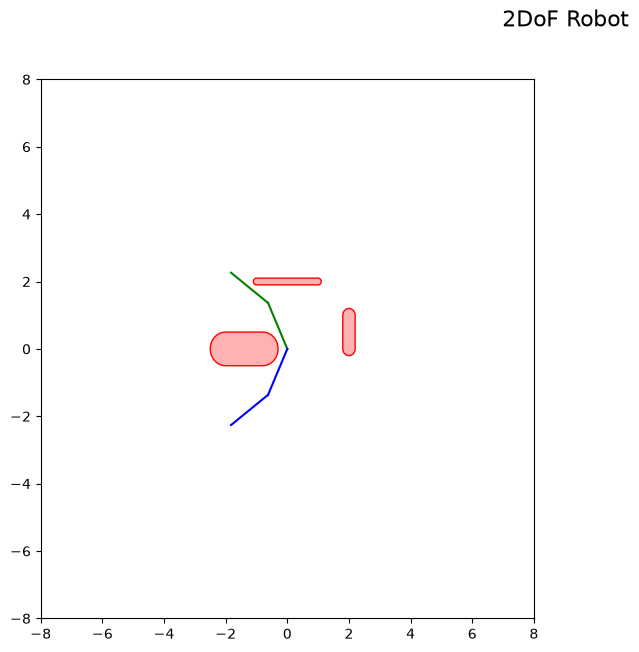

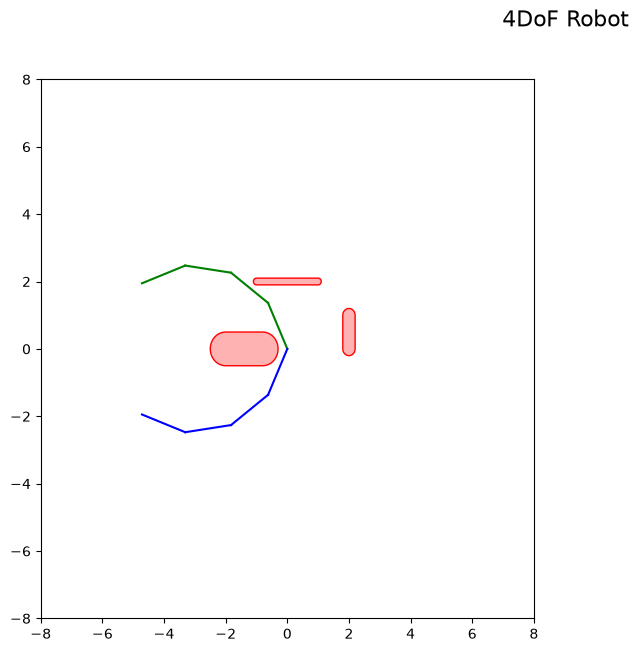

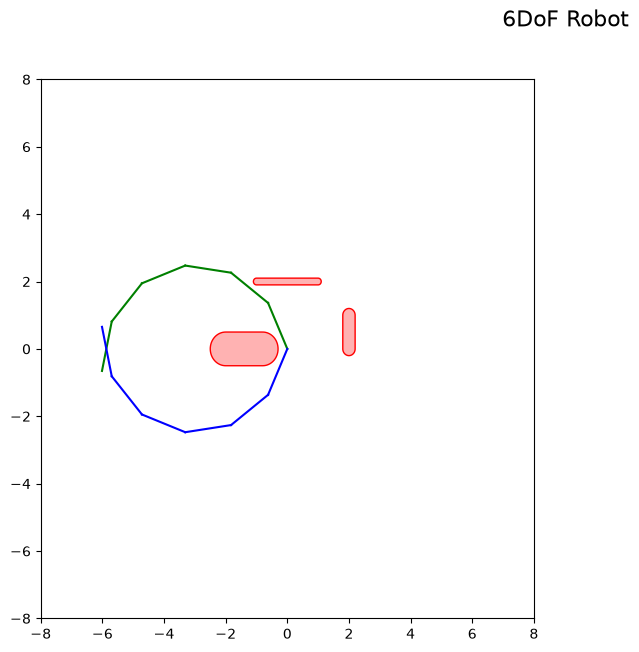

In [35]:
for key, producer in list(planarRobotDict.items()):
    fig_local = plt.figure(figsize=(14, 7))
    ## right figure for robot start position
    fig_local.suptitle(f"{key} Robot", fontsize=16)
    ax1 = fig_local.add_subplot(1, 2, 1)
    ax1.set_xlim([-8,8])
    ax1.set_ylim([-8,8])
    producer[3].drawObstacles(ax1, True)
    producer[0].move(producer[1])
    planarRobotVisualize(producer[0], ax1, "g")
    producer[0].move(producer[2])
    planarRobotVisualize(producer[0], ax1, "b" )

plt.show()

In [ ]:
resultList = list()
for robotKey, robot in list(planarRobotDict.items()):
    start = [robot[1]]
    goal  = [robot[2]]

    benchmark = Benchmark(
            "Obst_" + robotKey,
            robot[3],
            start,
            goal,
            "Obst_" + robotKey,
            2,
        )
    
    for plannerKey, planner in list(robot[4].items()):
        print ("Planning: " + robotKey + " for " + plannerKey)

        IPPerfMonitor.clearData()

        rrt = planner[0](robot[3])
        try:
            
            resultList.append(ResultCollection(plannerKey,
                                        0,
                                        rrt, 
                                        benchmark, 
                                        res[0] if isinstance(res := rrt.planPath(start, goal, planner[1]), tuple) else res,
                                        IPPerfMonitor.dataFrame()
                                        ),
                        )
        except Exception as e:
        #    throw e
            print ("PLANNING ERROR ! PLANNING ERROR ! PLANNING ERROR ", e)
            print(traceback.format_exc())
            pass
        ## plan path from start to goal



Planning: 2DoF for RRT
Planning: 2DoF for RRTEdge
Planning: 2DoF for BiRRTEdge
Planning: 4DoF for RRT
Planning: 4DoF for RRTEdge
Planning: 4DoF for BiRRTEdge
Planning: 6DoF for RRT
Planning: 6DoF for RRTEdge
Planning: 6DoF for BiRRTEdge
  plannerName  benchmark  runs  sucess_rate  avg_planpath_time  avg_num_nodes  \
0         RRT  Obst_2DoF     1          1.0           1.741176           11.0   
1     RRTEdge  Obst_2DoF     1          1.0           3.401417           31.0   
2   BiRRTEdge  Obst_2DoF     1          1.0           3.895004           38.0   
3         RRT  Obst_4DoF     1          1.0          21.274061           11.0   
4     RRTEdge  Obst_4DoF     1          1.0         183.931654          102.0   
5   BiRRTEdge  Obst_4DoF     1          1.0         196.698070          173.0   
6         RRT  Obst_6DoF     1          1.0       11320.828041          671.0   
7     RRTEdge  Obst_6DoF     1          1.0        2529.690446          456.0   
8   BiRRTEdge  Obst_6DoF     1    

In [ ]:
statistics = gatherData(resultList)
print(statistics)


  plannerName  benchmark  planpath_time  num_nodes  num_edges  \
0         RRT  Obst_2DoF       1.741176         11         10   
1     RRTEdge  Obst_2DoF       3.401417         31         30   
2   BiRRTEdge  Obst_2DoF       3.895004         38         37   
3         RRT  Obst_4DoF      21.274061         11         10   
4     RRTEdge  Obst_4DoF     183.931654        102        101   
5   BiRRTEdge  Obst_4DoF     196.698070        173        172   
6         RRT  Obst_6DoF   11320.828041        671        670   
7     RRTEdge  Obst_6DoF    2529.690446        456        455   
8   BiRRTEdge  Obst_6DoF    1349.374567        449        448   

   divide_edges_calls  line_collision_checks  path_length  solution_length  \
0                   0                     37     6.998488                6   
1                   9                     89     7.951519               14   
2                  11                     89     8.422066               14   
3                   0                

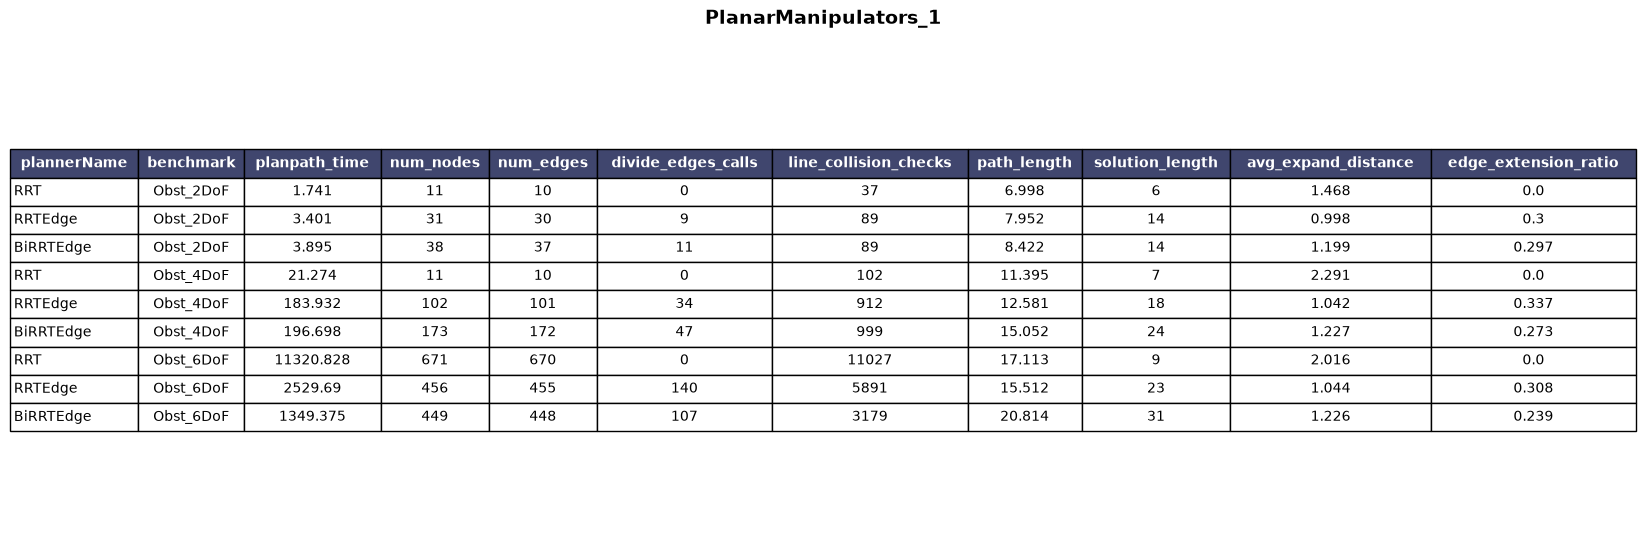

In [47]:
plot_table(statistics, "PlanarManipulators_1")

In [21]:
for result in resultList:
    print(result.plannerFactoryName + " - " + result.benchmark.name)
    print(result.solution)

RRT - Obst_2DoF
['start', 1, 2, 6, 7, 8, 'goal']
RRTEdge - Obst_2DoF
['start', 9, 3, 1, 15, 13, 21, 4, 7, 5, 26, 25, 28, 29, 'goal']
BiRRTEdge - Obst_2DoF
['start', 29, 2, 4, 17, 7, 13, 10, 37, 36, 9, 26, 5, 6, 'goal']
RRT - Obst_4DoF
['start', 1, 4, 5, 6, 8, 9, 'goal']
RRTEdge - Obst_4DoF
['start', 6, 44, 1, 64, 89, 2, 7, 8, 10, 27, 60, 71, 58, 83, 85, 82, 101, 'goal']
BiRRTEdge - Obst_4DoF
['start', 5, 9, 8, 77, 100, 12, 107, 14, 22, 53, 32, 40, 122, 156, 163, 170, 172, 7, 154, 6, 20, 3, 11, 'goal']
RRT - Obst_6DoF
['start', 1, 7, 8, 88, 355, 642, 665, 666, 'goal']
RRTEdge - Obst_6DoF
['start', 3, 1, 15, 34, 14, 27, 45, 22, 21, 237, 35, 36, 105, 127, 336, 349, 335, 397, 449, 452, 453, 454, 'goal']
BiRRTEdge - Obst_6DoF
['start', 5, 4, 30, 13, 12, 133, 16, 55, 20, 22, 257, 24, 141, 91, 70, 69, 76, 98, 251, 200, 239, 238, 408, 445, 444, 448, 33, 19, 7, 8, 'goal']


In [45]:
animateResult = resultList[8]
animateSolution(animateResult.planner, animateResult.benchmark.collisionChecker, 
                animateResult.solution, rrtPRMVisualize, [(-4,4),(-4,4)])

Ergebnisse:
* kantenbasierter RRT hat mehr Knoten in der Lösung und der bidirektionale noch mehr
* knotenbaisert RRT ist bei den einfachen Varianten schneller, aber bei 6DoF ist die Schnelligkeit auf einmal getauscht (biDirec => kantenbasiert => knotenbaisert)
    * Das gleiche gilt für Anzahl der Knoten und Kanten
* In den Animationen kann man erkennen, dass alle Algorithmen Probleme damit haben nicht mit einem Objekt oder mit sich selbst zu kollidieren
    * Das liegt daran, dass erstens wir nicht mehr mit Punkten arbeiten, sondern die Zusammenhängende Linien 
* Die Berechnungszeit wächst exponentiell mit den DoFs

## 8. Visualisierungen und Animationen

Zeigen Sie Suchraum, Roadmap/Baum, Pfad, Kollisionen, Statistiken oder Animationen.

In [ ]:
# Visualisierungen erzeugen.
pass

### 2-DoF Varianten Vergleich

In [ ]:
import matplotlib.pyplot as plt

for (planner_name, benchmark), result in best_runs_2dof.items():
    fig_local = plt.figure(figsize=(10,10))
    ax = fig_local.add_subplot(1,1,1)
    title = planner_name + " - " + benchmark.name
    if result.solution == []:
        title += " (No path found!)"
    title += "\n Assumed complexity level " + str(result.benchmark.level)
    ax.set_title(title)
    try:
        plannerFactory[result.plannerFactoryName][2](result.planner, result.solution, ax=ax, nodeSize=100)
    except Exception as e:
        print ("Error", e)
        pass

## 9. Ergebnisse

Stellen Sie Ergebnisse in Tabellen und Diagrammen dar und erklären Sie beobachtete Effekte.

In [ ]:
# Ergebnisse als DataFrame/Tabelle/Plot darstellen.
pass

### 2-DoF Varianten Vergleich

In [ ]:
plot_tables_per_benchmark(table_2dof_statistics)

## 10. Diskussion

Diskutieren Sie, was funktioniert hat, wo Grenzen liegen, welche Parameter wichtig sind und wie belastbar die Ergebnisse sind.

## 11. Fazit

Fassen Sie die wichtigsten Erkenntnisse knapp zusammen.

## 12. Verwendung von KI-Werkzeugen

Dokumentieren Sie, wofür KI verwendet wurde, welche Vorschläge übernommen oder verworfen wurden und wie die Korrektheit geprüft wurde.
* Für Kapitel 2-DoF Varianten Evaluation, zum Statistiken sammeln und Tabelle plotten; verifiziert indem bei kleinem Besspiel Werte manuell nachgerechnet wurden

## 13. Präsentationsnotizen

Notieren Sie die Kernaussagen für die Präsentation: Problem, Ansatz, wichtigste Visualisierung, wichtigste Ergebnisse und wichtigste Erkenntnis.